In [1]:
# ============================================================
# Cell 1 : Configuration  ← only edit this cell
# ============================================================
import os
from pathlib import Path
from collections import defaultdict

DATASET_ROOT = Path(r"E:\Downloads\Arabic Words Dataset")
FILE_EXT     = ".mp4"           # change to .avi / .jpg etc. if needed
SPLITS       = ["train", "test"] # sub-folders to check; leave empty [] to scan root

# ── Sanity check ─────────────────────────────────────────────
if not DATASET_ROOT.exists():
    raise FileNotFoundError(f"Dataset root not found:\n  {DATASET_ROOT}")

print("=" * 60)
print("KArSL DATASET STRUCTURE CHECKER")
print("=" * 60)
print(f"Root  : {DATASET_ROOT}")
print(f"Ext   : {FILE_EXT}")

# ── Discover the actual folder tree ──────────────────────────
def scan_split(base: Path):
    """
    Walk base recursively and collect every folder that contains
    at least one FILE_EXT file directly inside it (leaf class folders).
    Returns a dict: {relative_folder_path -> file_count}
    """
    class_map = {}
    for dirpath, dirnames, filenames in os.walk(str(base)):
        videos = [f for f in filenames if f.lower().endswith(FILE_EXT)]
        if videos:
            rel = Path(dirpath).relative_to(base)
            class_map[str(rel)] = len(videos)
    return class_map

print()
grand_total  = 0
split_found  = []

# Check each split (or the root itself if SPLITS is empty)
scan_targets = [(s, DATASET_ROOT / s) for s in SPLITS if (DATASET_ROOT / s).exists()]
missing      = [s for s in SPLITS if not (DATASET_ROOT / s).exists()]

if missing:
    print(f"⚠️  Missing splits: {missing}")

if not scan_targets:
    # No split sub-folders found — scan root directly
    print("No train/test sub-folders found. Scanning root directly.")
    scan_targets = [("(root)", DATASET_ROOT)]

for split_name, split_path in scan_targets:
    print(f"📂  Scanning {split_name.upper()} → {split_path}")
    class_map = scan_split(split_path)

    total_files   = sum(class_map.values())
    grand_total  += total_files
    n_classes     = len(class_map)
    empty_classes = [k for k, v in class_map.items() if v == 0]

    print(f"    Class folders with videos : {n_classes}")
    print(f"    Total {FILE_EXT} files      : {total_files}")

    if n_classes == 0:
        print(f"    ❌ NO VIDEO FILES FOUND under {split_path}")
        print(f"       Top-level contents: {[p.name for p in split_path.iterdir()][:10]}")
    else:
        counts = sorted(class_map.values())
        print(f"    Samples / class  — min: {counts[0]}  max: {counts[-1]}  "
              f"mean: {sum(counts)/len(counts):.1f}  median: {counts[len(counts)//2]}")

        # depth distribution
        depth_dist = defaultdict(int)
        for k in class_map:
            depth_dist[k.count(os.sep) + 1] += 1
        print(f"    Nesting depth    — {dict(sorted(depth_dist.items()))}")

        # show a sample of class folder names
        sample = sorted(class_map.keys())[:6]
        print(f"    Sample folders   — {sample}" + (" ..." if n_classes > 6 else ""))

        if empty_classes:
            print(f"    ⚠️  Empty class folders: {empty_classes}")
        else:
            print(f"    ✅  No empty class folders.")
    print()

print(f"GRAND TOTAL {FILE_EXT} files across all splits: {grand_total}")


KArSL DATASET STRUCTURE CHECKER
Root  : E:\Downloads\Arabic Words Dataset
Ext   : .mp4

📂  Scanning TRAIN → E:\Downloads\Arabic Words Dataset\train
    Class folders with videos : 502
    Total .mp4 files      : 21087
    Samples / class  — min: 16  max: 84  mean: 42.0  median: 42
    Nesting depth    — {2: 502}
    Sample folders   — ['0001-0070\\0001', '0001-0070\\0002', '0001-0070\\0003', '0001-0070\\0004', '0001-0070\\0005', '0001-0070\\0006'] ...
    ✅  No empty class folders.

📂  Scanning TEST → E:\Downloads\Arabic Words Dataset\test
    Class folders with videos : 502
    Total .mp4 files      : 4024
    Samples / class  — min: 1  max: 16  mean: 8.0  median: 8
    Nesting depth    — {2: 502}
    Sample folders   — ['0001-0070 (1)\\0001', '0001-0070 (1)\\0002', '0001-0070 (1)\\0003', '0001-0070 (1)\\0004', '0001-0070 (1)\\0005', '0001-0070 (1)\\0006'] ...
    ✅  No empty class folders.

GRAND TOTAL .mp4 files across all splits: 25111


In [2]:
# ============================================================
# Cell 2 : Deep Video Integrity Check (OpenCV)
# Tries to open every video and read its first frame.
# Prints a list of any corrupted / unreadable files.
# ============================================================
import cv2

print("=" * 60)
print("DEEP VIDEO INTEGRITY CHECK")
print("=" * 60)
print(f"Root : {DATASET_ROOT}")
print("Reading first frame of every video — this may take a few minutes...\n")

corrupted  = []
short      = []      # videos with < 5 readable frames
checked    = 0
MIN_FRAMES = 5       # anything below this is flagged as suspiciously short

for dirpath, _, filenames in os.walk(str(DATASET_ROOT)):
    videos = [f for f in filenames if f.lower().endswith(FILE_EXT)]
    for fname in videos:
        fpath = os.path.join(dirpath, fname)
        checked += 1
        cap = cv2.VideoCapture(fpath)
        if not cap.isOpened():
            corrupted.append(fpath)
            cap.release()
            continue
        # Count readable frames up to MIN_FRAMES
        readable = 0
        for _ in range(MIN_FRAMES):
            ret, _ = cap.read()
            if ret:
                readable += 1
            else:
                break
        cap.release()
        if readable == 0:
            corrupted.append(fpath)
        elif readable < MIN_FRAMES:
            short.append((fpath, readable))

        if checked % 200 == 0:
            print(f"  … checked {checked} files so far (corrupted: {len(corrupted)})")

print()
print("=" * 60)
print("RESULTS")
print("=" * 60)
print(f"Total videos checked  : {checked}")
print(f"Corrupted / unreadable: {len(corrupted)}")
print(f"Too short (<{MIN_FRAMES} frames)  : {len(short)}")

if corrupted:
    print("\n❌ CORRUPTED FILES (delete these before training):")
    for p in corrupted[:20]:
        print(f"   {p}")
    if len(corrupted) > 20:
        print(f"   ... and {len(corrupted)-20} more.")
else:
    print("\n✅ All videos opened and read successfully.")

if short:
    print(f"\n⚠️  SUSPICIOUSLY SHORT VIDEOS ({len(short)} total):")
    for p, n in short[:10]:
        print(f"   {n} frames — {p}")
    if len(short) > 10:
        print(f"   ... and {len(short)-10} more.")


DEEP VIDEO INTEGRITY CHECK
Root : E:\Downloads\Arabic Words Dataset
Reading first frame of every video — this may take a few minutes...

  … checked 200 files so far (corrupted: 0)
  … checked 400 files so far (corrupted: 0)
  … checked 600 files so far (corrupted: 0)
  … checked 800 files so far (corrupted: 0)
  … checked 1000 files so far (corrupted: 0)
  … checked 1200 files so far (corrupted: 0)
  … checked 1400 files so far (corrupted: 0)
  … checked 1600 files so far (corrupted: 0)
  … checked 1800 files so far (corrupted: 0)
  … checked 2000 files so far (corrupted: 0)
  … checked 2200 files so far (corrupted: 0)
  … checked 2400 files so far (corrupted: 0)
  … checked 2600 files so far (corrupted: 0)
  … checked 2800 files so far (corrupted: 0)
  … checked 3000 files so far (corrupted: 0)
  … checked 3200 files so far (corrupted: 0)
  … checked 3400 files so far (corrupted: 0)
  … checked 3600 files so far (corrupted: 0)
  … checked 3800 files so far (corrupted: 0)
  … checked 

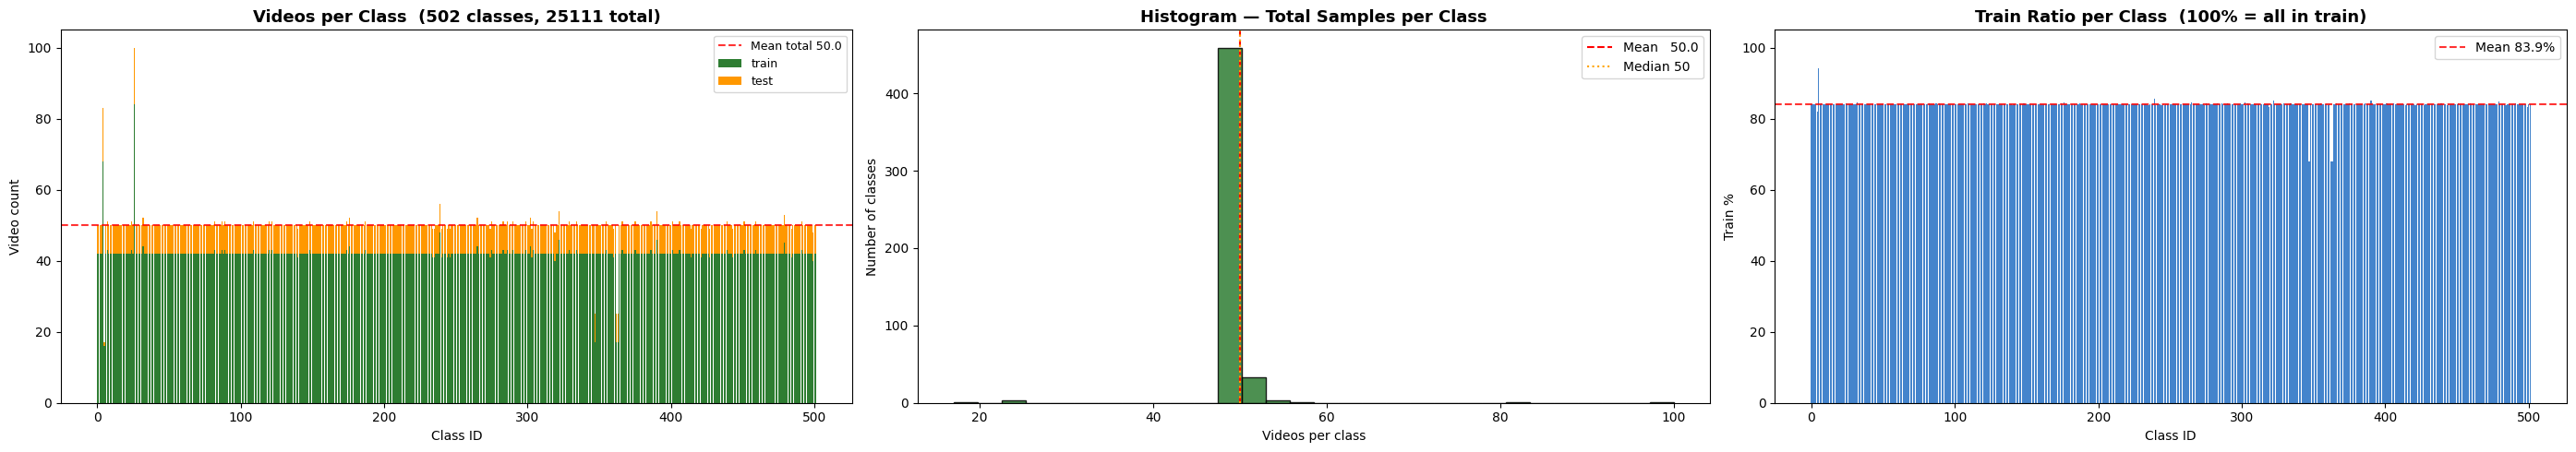

Classes         : 502
Train videos    : 21087   (84.0%)
Test  videos    : 4024   (16.0%)
Total videos    : 25111
Min per class   : 17
Max per class   : 100
Mean / Median   : 50.0 / 50
Empty classes   : none
Plot saved      : E:\Downloads\Arabic Words Dataset\class_distribution_check.png


In [3]:
# ============================================================
# Cell 3 : Class Distribution Plot
# Shows per-class video counts — helps spot imbalance.
# ============================================================
import matplotlib.pyplot as plt
import numpy as np
from collections import defaultdict

# Collect per-class counts (sum train + test per numeric class ID)
train_counts = defaultdict(int)
test_counts  = defaultdict(int)

for split, bucket in [("train", train_counts), ("test", test_counts)]:
    split_path = DATASET_ROOT / split
    if not split_path.exists():
        continue
    for dirpath, _, filenames in os.walk(str(split_path)):
        videos = [f for f in filenames if f.lower().endswith(FILE_EXT)]
        if videos:
            class_id = Path(dirpath).name
            bucket[class_id] += len(videos)

all_ids = sorted(
    set(train_counts) | set(test_counts),
    key=lambda x: int(x) if x.isdigit() else x
)

if not all_ids:
    print("No videos found — nothing to plot.")
else:
    tr  = [train_counts.get(i, 0) for i in all_ids]
    te  = [test_counts.get(i,  0) for i in all_ids]
    tot = [a + b for a, b in zip(tr, te)]
    n   = len(all_ids)

    fig, axes = plt.subplots(1, 3, figsize=(28, 5))

    # ── Stacked bar: train vs test per class ──
    x = range(n)
    axes[0].bar(x, tr, color='#2E7D32', label='train', edgecolor='none')
    axes[0].bar(x, te, bottom=tr, color='#FF9800', label='test', edgecolor='none')
    axes[0].axhline(np.mean(tot), color='red', linestyle='--', alpha=0.8,
                    label=f'Mean total {np.mean(tot):.1f}')
    axes[0].set_title(f'Videos per Class  ({n} classes, {sum(tot)} total)', fontsize=13, fontweight='bold')
    axes[0].set_xlabel('Class ID')
    axes[0].set_ylabel('Video count')
    if n <= 120:
        axes[0].set_xticks(list(x))
        axes[0].set_xticklabels(all_ids, rotation=90, fontsize=5)
    axes[0].legend(fontsize=9)

    # ── Histogram of total counts ──
    axes[1].hist(tot, bins=min(30, n), color='#2E7D32', edgecolor='black', alpha=0.85)
    axes[1].axvline(np.mean(tot),   color='red',    linestyle='--', label=f'Mean   {np.mean(tot):.1f}')
    axes[1].axvline(np.median(tot), color='orange', linestyle=':',  label=f'Median {np.median(tot):.0f}')
    axes[1].set_title('Histogram — Total Samples per Class', fontsize=13, fontweight='bold')
    axes[1].set_xlabel('Videos per class')
    axes[1].set_ylabel('Number of classes')
    axes[1].legend()

    # ── Train / Test ratio per class ──
    ratios = [t / (t + e) if (t + e) > 0 else 0 for t, e in zip(tr, te)]
    axes[2].bar(x, [r * 100 for r in ratios], color='#1565C0', edgecolor='none', alpha=0.8)
    axes[2].axhline(np.mean([r * 100 for r in ratios]), color='red', linestyle='--', alpha=0.8,
                    label=f'Mean {np.mean(ratios)*100:.1f}%')
    axes[2].set_title('Train Ratio per Class  (100% = all in train)', fontsize=13, fontweight='bold')
    axes[2].set_xlabel('Class ID')
    axes[2].set_ylabel('Train %')
    axes[2].set_ylim([0, 105])
    if n <= 120:
        axes[2].set_xticks(list(x))
        axes[2].set_xticklabels(all_ids, rotation=90, fontsize=5)
    axes[2].legend()

    plt.tight_layout()
    out_png = DATASET_ROOT / 'class_distribution_check.png'
    plt.savefig(str(out_png), dpi=150, bbox_inches='tight')
    plt.show()

    print(f"Classes         : {n}")
    print(f"Train videos    : {sum(tr)}   ({sum(tr)/sum(tot)*100:.1f}%)")
    print(f"Test  videos    : {sum(te)}   ({sum(te)/sum(tot)*100:.1f}%)")
    print(f"Total videos    : {sum(tot)}")
    print(f"Min per class   : {min(tot)}")
    print(f"Max per class   : {max(tot)}")
    print(f"Mean / Median   : {np.mean(tot):.1f} / {np.median(tot):.0f}")
    empty = [i for i, c in zip(all_ids, tot) if c == 0]
    if empty:
        print(f"Empty classes   : {empty}")
    else:
        print("Empty classes   : none")
    print(f"Plot saved      : {out_png}")
